<a href="https://colab.research.google.com/drive/16AxbLnhHfVCBedYU8I-Z4dnt74ZvLzmd?usp=sharing">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 🔍 Cyber Crime Data Analysis Lab: Master Investigation Notebook

*NIELIT Ropar × Punjab Bureau of Investigation*

---
## Welcome, Investigator.
This interactive notebook is designed to train cyber police and forensic analysts in real-world data analysis workflows using Python. As cybercrimes grow in complexity, the ability to rapidly parse, clean, and analyze digital logs is a critical skill.

### 📋 Training Curriculum Overview
* **Module 1: Basics of Pandas** - Loading and exploring digital evidence.
* **Module 2: Data Cleaning** - Sanitizing logs for accurate forensic analysis.
* **Module 3: Investigation Techniques** - Profiling repeat offenders and financial tracking.
* **Module 4: Network Analysis** - Identifying malicious network traffic.
* **Module 5: Visualization** - Building compelling visual evidence for reporting.
* **Module 6: Case Study** - Fusing multiple datasets to pinpoint high-risk threats.
* **Final Task** - A capstone scenario to test your new capabilities.

---
### ⚙️ Setup and Environment
Before we begin, we must import our primary analytical tools.
- `pandas` acts as our digital ledger for structured data.
- `matplotlib.pyplot` is our canvas for drawing visual evidence.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Configure plot aesthetics for professional reporting
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Environment initialized. Ready for investigation.")

Environment initialized. Ready for investigation.


---
## 📁 Module 1: Basics of Pandas (Data Ingestion & Exploration)

**Investigator's Note:** Your data is your crime scene. Before you can look for clues, you must secure and survey the area. Here, we load three critical pieces of evidence: crime reports, network logs, and a suspect database.

**Files referenced in this module:**
1. `cyber_crime_logs.csv` - Records of reported incidents.
2. `network_activity.csv` - Traffic logs containing threat flags.
3. `suspect_profiles.csv` - Known intelligence on potential threat actors.

In [30]:
# Load the datasets into Pandas DataFrames
crime = pd.read_csv('https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/cyber_training_dataset/cyber_crime_logs.csv')
network = pd.read_csv('https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/cyber_training_dataset/network_activity.csv')
suspect = pd.read_csv('https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/cyber_training_dataset/suspect_profiles.csv')

# Survey the first 5 rows of the crime logs to understand the structure
display(crime.head())

,case_id,timestamp,crime_type,location,ip_address,user_id,device_type,amount_lost,status
0,CC0001,2026-03-28 08:41:24,Identity Theft,Mumbai,192.168.44.120,U3992,Mobile,6324,Open
1,CC0002,2026-03-13 08:41:24,Identity Theft,Chandigarh,192.168.19.89,U6310,Mobile,40940,Under Investigation
2,CC0003,2026-03-07 08:41:24,Phishing,Bangalore,192.168.133.236,U4436,Mobile,47465,Closed
3,CC0004,2026-03-07 08:41:24,Identity Theft,Bangalore,192.168.36.157,U5688,Laptop,32529,Under Investigation
4,CC0005,2026-03-09 08:41:24,Identity Theft,Bangalore,192.168.166.163,U2326,Mobile,31716,Open


### 1.1 Structural Exploration
To trust our evidence, we need to know its shape and data types.
- `.info()` tells us if any columns have missing values (nulls) and what type of data they hold.
- `.describe()` gives us statistical summaries (averages, maximums) of numerical data, like `amount_lost`.

In [31]:
print("--- CRIME LOGS INFO ---")
crime.info()

print("\n--- STATISTICAL SUMMARY ---")
display(crime.describe())

--- CRIME LOGS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   case_id      500 non-null    object
 1   timestamp    500 non-null    object
 2   crime_type   500 non-null    object
 3   location     500 non-null    object
 4   ip_address   500 non-null    object
 5   user_id      500 non-null    object
 6   device_type  500 non-null    object
 7   amount_lost  500 non-null    int64 
 8   status       500 non-null    object
dtypes: int64(1), object(8)
memory usage: 35.3+ KB

--- STATISTICAL SUMMARY ---


,amount_lost
count,500.000000
mean,24736.384000
std,13809.415103
min,304.000000
25%,13343.000000
50%,24688.500000
75%,36017.750000
max,49843.000000


---
## 🧹 Module 2: Data Cleaning (Sanitizing the Evidence)

**Investigator's Note:** Raw data is often messy. Duplicate entries can inflate financial loss numbers, and improper timestamp formatting can destroy a digital alibi. We must clean the data before presenting it in a court of law or official report.

In [32]:
# 1. Convert timestamps from plain text to strict datetime objects for timeline analysis
crime['timestamp'] = pd.to_datetime(crime['timestamp'], errors='coerce')

# 2. Remove duplicate case entries to prevent artificial inflation of crime statistics
initial_count = len(crime)
crime = crime.drop_duplicates()
final_count = len(crime)
print(f"Removed {initial_count - final_count} duplicate records.")

# 3. Check for any remaining missing values (Nulls)
print("\nMissing values per column:")
print(crime.isnull().sum())

Removed 0 duplicate records.

Missing values per column:
case_id        0
timestamp      0
crime_type     0
location       0
ip_address     0
user_id        0
device_type    0
amount_lost    0
status         0
dtype: int64


---
## 🕵️‍♂️ Module 3: Investigation Techniques

Now we begin our active investigation. We will use grouping and merging to uncover hidden patterns.

### Task 3.1: Find Repeat Offenders (Top IPs)
Threat actors often reuse infrastructure. By grouping our logs by IP address, we can spot serial offenders.

In [33]:
# Count occurrences of each IP address and sort them descending
top_ips = crime.groupby('ip_address').size().sort_values(ascending=False).head(5)

print("Top 5 Most Frequent IP Addresses in Crime Logs:")
print(top_ips)

Top 5 Most Frequent IP Addresses in Crime Logs:
ip_address
192.168.233.169    2
192.168.47.240     2
192.168.252.159    1
192.168.251.9      1
192.168.251.187    1
dtype: int64


### Task 3.2: Financial Impact Analysis
Where is the most money being lost? Grouping by `crime_type` helps prioritize resources.

In [34]:
# Calculate total financial loss categorized by the type of crime
financial_impact = crime.groupby('crime_type')['amount_lost'].sum().sort_values(ascending=False)

print("Total Money Lost by Crime Type (in INR/USD):")
print(financial_impact)

Total Money Lost by Crime Type (in INR/USD):
crime_type
Identity Theft    3359611
Ransomware        3213030
Phishing          3135208
UPI Fraud         2660343
Name: amount_lost, dtype: int64


### Task 3.3: Intelligence Fusion (Merging Datasets)
An IP address is just a number until you map it to a suspect. We will use a `LEFT JOIN` to attach suspect profiles to our crime logs based on the shared `ip_address`.

In [35]:
merged_evidence


,case_id,timestamp,crime_type,location,ip_address,user_id,device_type,amount_lost,status,suspect_id,name,age,previous_cases,risk_level
0,CC0001,2026-03-28 08:41:24,Identity Theft,Mumbai,192.168.44.120,U3992,Mobile,6324,Open,NaN,NaN,NaN,NaN,NaN
1,CC0002,2026-03-13 08:41:24,Identity Theft,Chandigarh,192.168.19.89,U6310,Mobile,40940,Under Investigation,NaN,NaN,NaN,NaN,NaN
2,CC0003,2026-03-07 08:41:24,Phishing,Bangalore,192.168.133.236,U4436,Mobile,47465,Closed,NaN,NaN,NaN,NaN,NaN
3,CC0004,2026-03-07 08:41:24,Identity Theft,Bangalore,192.168.36.157,U5688,Laptop,32529,Under Investigation,NaN,NaN,NaN,NaN,NaN
4,CC0005,2026-03-09 08:41:24,Identity Theft,Bangalore,192.168.166.163,U2326,Mobile,31716,Open,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CC0496,2026-04-24 08:41:24,UPI Fraud,Chandigarh,192.168.179.60,U4085,Desktop,13289,Under Investigation,NaN,NaN,NaN,NaN,NaN
496,CC0497,2026-04-03 08:41:24,Identity Theft,Bangalore,192.168.143.66,U1502,Desktop,25693,Open,NaN,NaN,NaN,NaN,NaN
497,CC0498,2026-03-30 08:41:24,UPI Fraud,Mumbai,192.168.150.187,U9441,Desktop,3859,Under Investigation,NaN,NaN,NaN,NaN,NaN
498,CC0499,2026-03-18 08:41:24,UPI Fraud,Chandigarh,192.168.218.75,U5071,Desktop,17493,Under Investigation,NaN,NaN,NaN,NaN,NaN


In [36]:
# Merge crime logs with suspect intelligence
merged_evidence = pd.merge(crime, suspect, on='ip_address', how='left')

# Display a sample of the fused data
display(merged_evidence[['case_id', 'ip_address', 'crime_type', 'suspect_id', 'risk_level']].head())

,case_id,ip_address,crime_type,suspect_id,risk_level
0,CC0001,192.168.44.120,Identity Theft,NaN,NaN
1,CC0002,192.168.19.89,Identity Theft,NaN,NaN
2,CC0003,192.168.133.236,Phishing,NaN,NaN
3,CC0004,192.168.36.157,Identity Theft,NaN,NaN
4,CC0005,192.168.166.163,Identity Theft,NaN,NaN


---
## 📡 Module 4: Network Analysis

**Investigator's Note:** The `network_activity.csv` dataset contains broader network logs. Systems like Intrusion Detection Systems (IDS) flag suspicious traffic with a `threat_flag = 1`. Let's isolate this malicious traffic.

In [37]:
# Filter the network dataset to only show rows where threat_flag is 1
threat_logs = network[network['threat_flag'] == 1]

print(f"Found {len(threat_logs)} suspicious network events.")
display(threat_logs.head())

Found 263 suspicious network events.


,log_id,timestamp,ip_address,url_accessed,response_code,bytes_transferred,threat_flag
0,L0001,2026-03-23 08:41:24,192.168.43.133,http://upi-fraud.net,404,650,1
1,L0002,2026-04-14 08:41:24,192.168.20.67,http://normal.com,404,1280,1
2,L0003,2026-05-03 08:41:24,192.168.164.92,http://fakebank.com,403,2627,1
3,L0004,2026-04-24 08:41:24,192.168.177.87,http://secure-site.com,200,3187,1
4,L0005,2026-03-16 08:41:24,192.168.235.211,http://fakebank.com,404,3497,1


---
## 📊 Module 5: Visualizing the Evidence

Numbers in a table rarely convince a jury or command officer. Visualizations tell a clear story.

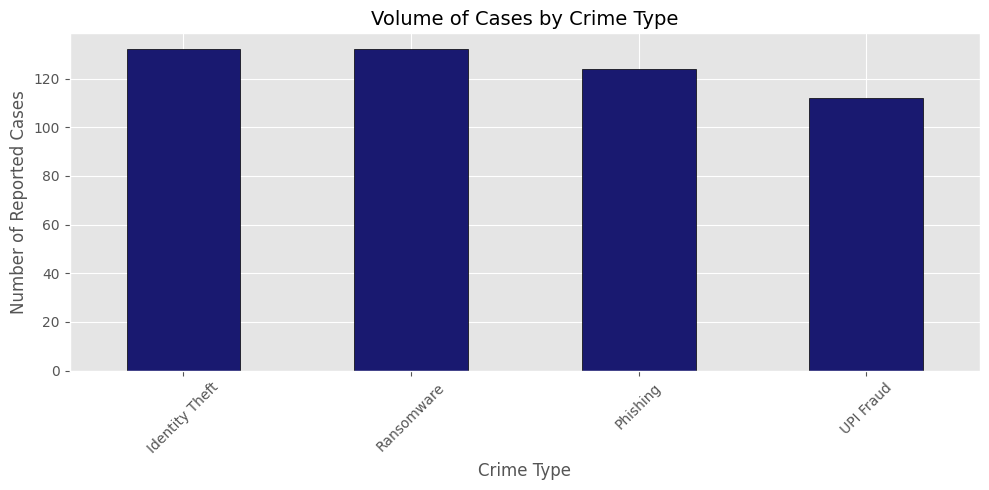

In [38]:
# Visualization 1: Crime Distribution (Bar Chart)
plt.figure(figsize=(10, 5))
crime_counts = crime['crime_type'].value_counts()
crime_counts.plot(kind='bar', color='midnightblue', edgecolor='black')

plt.title("Volume of Cases by Crime Type")
plt.xlabel("Crime Type")
plt.ylabel("Number of Reported Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

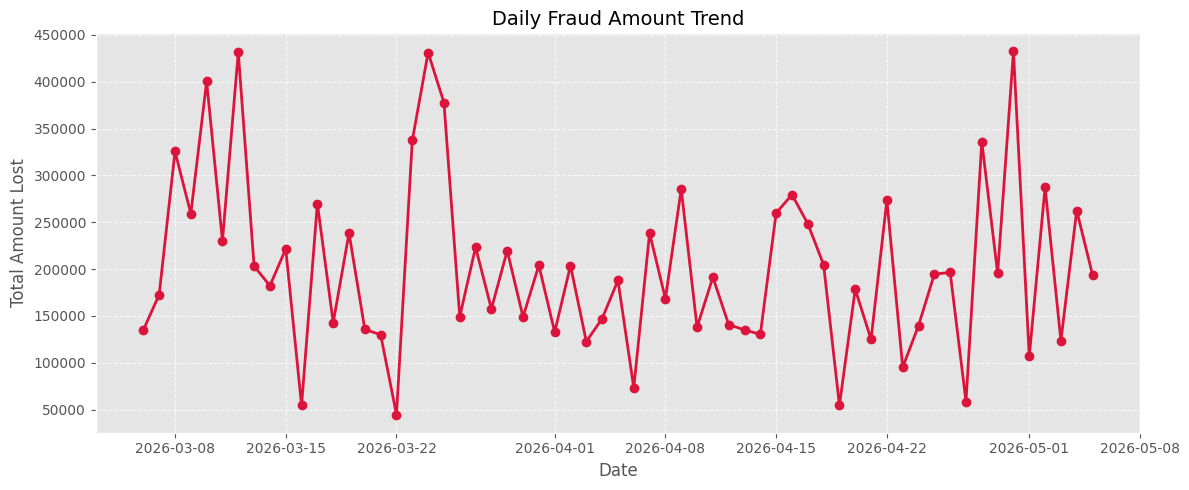

In [39]:
# Visualization 2: Fraud Trend Over Time (Line Chart)
# Grouping by the DATE portion of the timestamp to see daily trends
plt.figure(figsize=(12, 5))
daily_loss = crime.groupby(crime['timestamp'].dt.date)['amount_lost'].sum()

daily_loss.plot(kind='line', color='crimson', marker='o', linewidth=2)
plt.title("Daily Fraud Amount Trend")
plt.xlabel("Date")
plt.ylabel("Total Amount Lost")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
## 🔎 Module 6: Master Case Study

**Objective:** Identify the single most dangerous IP address by synthesizing case counts, financial damages, and IDS threat flags.

In [40]:
# Step 1: Aggregate crime data per IP
ip_stats = crime.groupby('ip_address').agg({
    'case_id': 'count',       # How many crimes?
    'amount_lost': 'sum'      # How much damage?
}).rename(columns={'case_id': 'num_cases'})

# Step 2: Sum threat flags from network activity per IP
threat_counts = network.groupby('ip_address')['threat_flag'].sum()

# Step 3: Join the tables together
master_dossier = ip_stats.join(threat_counts, on='ip_address').fillna(0)

# Step 4: Sort by the most critical metrics to identify the 'Big Fish'
most_dangerous = master_dossier.sort_values(by=['num_cases', 'amount_lost', 'threat_flag'], ascending=False)

print("--- HIGH VALUE TARGET DOSSIER ---")
display(most_dangerous.head(5))

--- HIGH VALUE TARGET DOSSIER ---


,num_cases,amount_lost,threat_flag
ip_address,,,
192.168.233.169,2,59170,0.0
192.168.47.240,2,34583,0.0
192.168.123.206,1,49843,0.0
192.168.40.213,1,49833,0.0
192.168.174.84,1,49583,0.0


---
## 🏆 Final Challenge: The Officer's Trial

**Scenario:** The Cyber Cell has received a tip regarding a high-profile phishing ring operating on weekends.

**Your Task:**
1. Filter the `crime` dataset to show only `Phishing` incidents.
2. Extract the day of the week from the `timestamp`.
3. Create a bar chart showing the number of Phishing attacks per day of the week.
4. Identify the highest-risk day and write a short summary of your findings.

*Use the empty code cell below to write your solution.*

In [42]:
# WRITE YOUR CODE HERE:


crimedf = pd.read_csv('https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/cyber_training_dataset/cyber_crime_logs.csv')

crimedf.head()

,case_id,timestamp,crime_type,location,ip_address,user_id,device_type,amount_lost,status
0,CC0001,2026-03-28 08:41:24,Identity Theft,Mumbai,192.168.44.120,U3992,Mobile,6324,Open
1,CC0002,2026-03-13 08:41:24,Identity Theft,Chandigarh,192.168.19.89,U6310,Mobile,40940,Under Investigation
2,CC0003,2026-03-07 08:41:24,Phishing,Bangalore,192.168.133.236,U4436,Mobile,47465,Closed
3,CC0004,2026-03-07 08:41:24,Identity Theft,Bangalore,192.168.36.157,U5688,Laptop,32529,Under Investigation
4,CC0005,2026-03-09 08:41:24,Identity Theft,Bangalore,192.168.166.163,U2326,Mobile,31716,Open


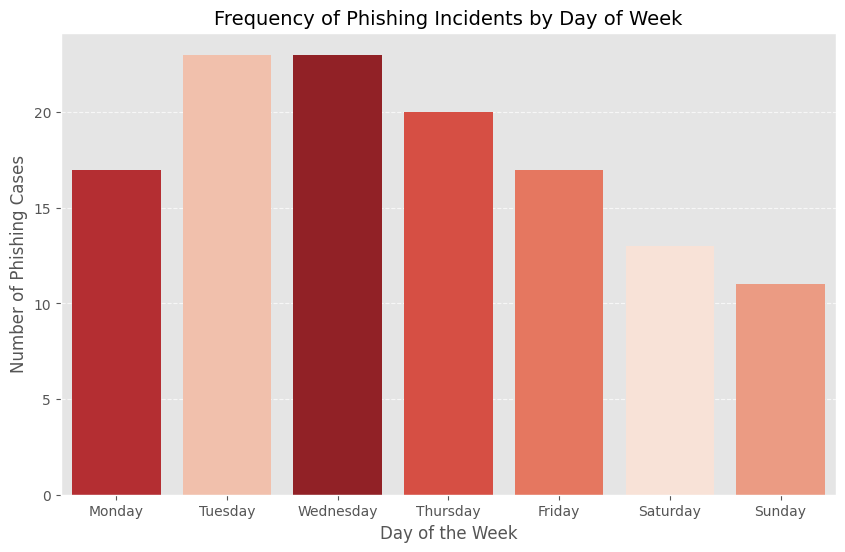

--- INVESTIGATION SUMMARY ---
Highest Risk Day: Tuesday with 23 incidents.


In [45]:
import seaborn as sns

# 1. Ensure timestamp is datetime and extract day of week
crimedf['timestamp'] = pd.to_datetime(crimedf['timestamp'])
crimedf['day_of_week'] = crimedf['timestamp'].dt.day_name()

# 2. Filter for Phishing incidents
phishing_data = crimedf[crimedf['crime_type'] == 'Phishing']

# 3. Define the order of days for the plot
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 4. Create the visualization
plt.figure(figsize=(10, 6))
# Fixed warning by assigning x to hue and setting legend=False
sns.countplot(data=phishing_data, x='day_of_week', order=day_order, hue='day_of_week', palette='Reds', legend=False)

plt.title('Frequency of Phishing Incidents by Day of Week', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Phishing Cases')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Identify highest risk day
risk_summary = phishing_data['day_of_week'].value_counts()
highest_day = risk_summary.idxmax()
highest_count = risk_summary.max()
print(f"--- INVESTIGATION SUMMARY ---")
print(f"Highest Risk Day: {highest_day} with {highest_count} incidents.")



---



# Step1:

<img src="https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/cyber_training_dataset/1.jpeg">

# Step2:

<img src="https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/cyber_training_dataset/2.jpeg">

# Step3:

<img src="https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/cyber_training_dataset/3.jpeg">